# SMS SPAM CLASSIFIER PROJECT

In [1]:
import numpy as np
import pandas as pd

In [8]:
df = pd.read_csv("./dataset/spam.csv", encoding="latin-1")

In [9]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
3029,ham,"Also sir, i sent you an email about how to log...",NaN,NaN,NaN
1886,spam,Dear 0776xxxxxxx U've been invited to XCHAT. T...,NaN,NaN,NaN
3320,ham,Yo im right by yo work,NaN,NaN,NaN
1377,spam,Double Mins & Double Txt & 1/2 price Linerenta...,NaN,NaN,NaN
2345,ham,"Hi this is yijue, can i meet u at 11 tmr?",NaN,NaN,NaN


In [10]:
df.shape

(5572, 5)

## Steps:
1. Data Cleaning
2. EDA
3. Text Preprossesing
4. Model Building
5. Evaluation
6. Improvent
7. Website
8. Deployment

## 1. DATA CLEANING

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [12]:
# Drop last 3 columns - Pretty much useless
df.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"], inplace=True)

In [13]:
df.sample(5)

,v1,v2
5139,ham,Oh shut it. Omg yesterday I had a dream that I...
3596,spam,Congratulations YOU'VE Won. You're a Winner in...
5493,ham,I think if he rule tamilnadu..then its very to...
3718,spam,"Thanks for your ringtone order, reference numb..."
2143,ham,You stayin out of trouble stranger!!saw Dave t...


In [14]:
# Renaming columns v1,v2 as they are not descriptive
df.rename(columns={"v1" : "target", "v2":"text"}, inplace=True)

In [15]:
df.sample(5)

,target,text
2911,ham,You didn't have to tell me that...now i'm thin...
1910,ham,Becoz its &lt;#&gt; jan whn al the post ofic...
4687,ham,Hmmm.but you should give it on one day..
1327,spam,Ur balance is now å£500. Ur next question is: ...
4227,ham,Have you started in skye


In [16]:
# We need integer target values so lets transform those
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

In [19]:
df["target"] = encoder.fit_transform(df["target"])

In [20]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# Missing values check
df.isnull().sum()

target    0
text      0
dtype: int64

In [24]:
# Check for duplicate values
df.duplicated().sum()

np.int64(403)

In [25]:
# Remove duplicate
df.drop_duplicates(keep='first', inplace=True)

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.shape

(5169, 2)

## 2. EDA

In [29]:
# Check percent of data that is spam and that is ham
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

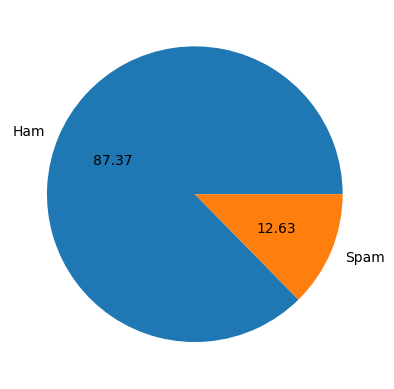

In [ ]:
# we could create a pie chart to show the balance
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels = ["Ham","Spam"], autopct="%0.2f")
plt.show()

- Data is Imbalanced

In [37]:
import nltk

In [44]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\bhand\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\bhand\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

We will create new columns in df
1. Number of characters in the text
2. Number of words in the sms
3. Number of sentenses in the sms

In [41]:
# 1
df['num_characters'] = df['text'].apply(len)

In [42]:
df.head(5)

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [47]:
# 2
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [48]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [51]:
# 3
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))


In [52]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [ ]:
# Overall Analysis
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [55]:
# Comparing only Ham messages
df[df['target'] == 0][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [56]:
df[df['target'] == 1][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [57]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

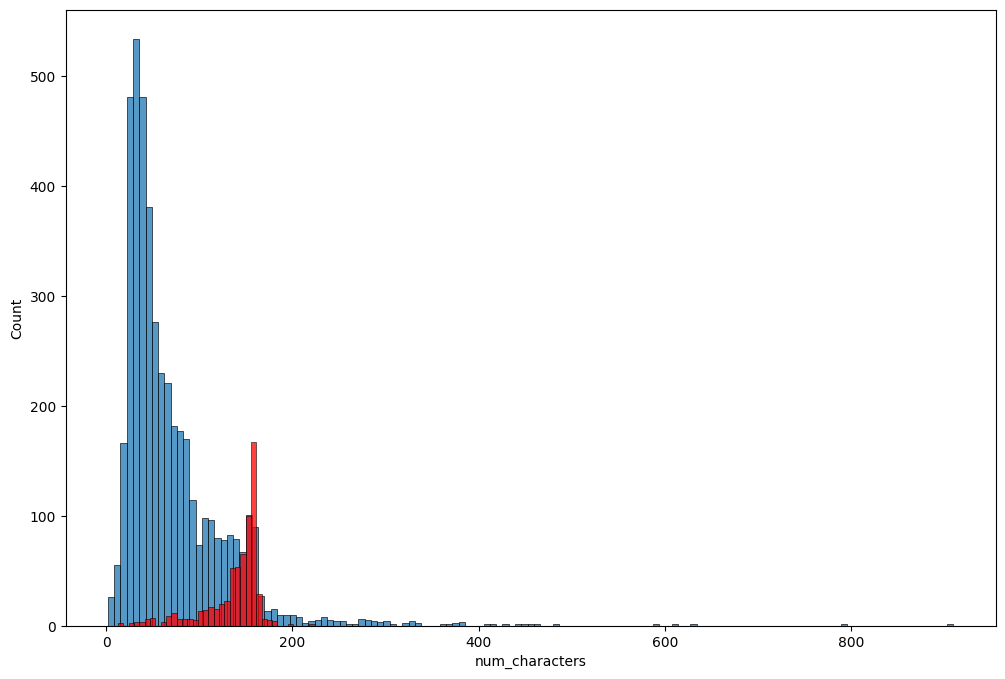

In [70]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'], color='red')

<Axes: xlabel='num_words', ylabel='Count'>

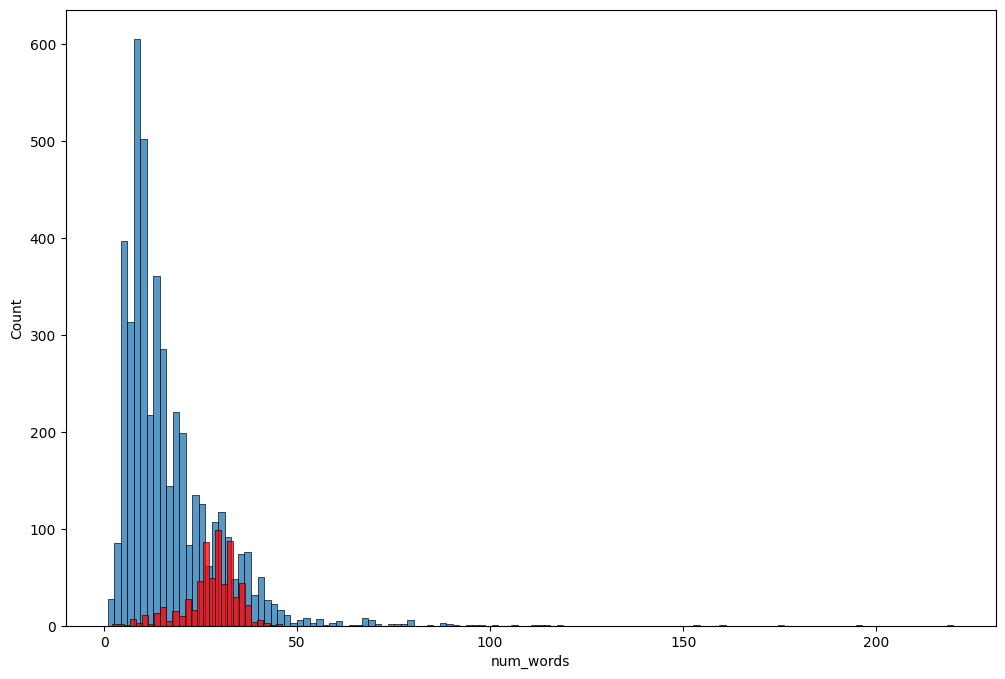

In [71]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'], color='red')

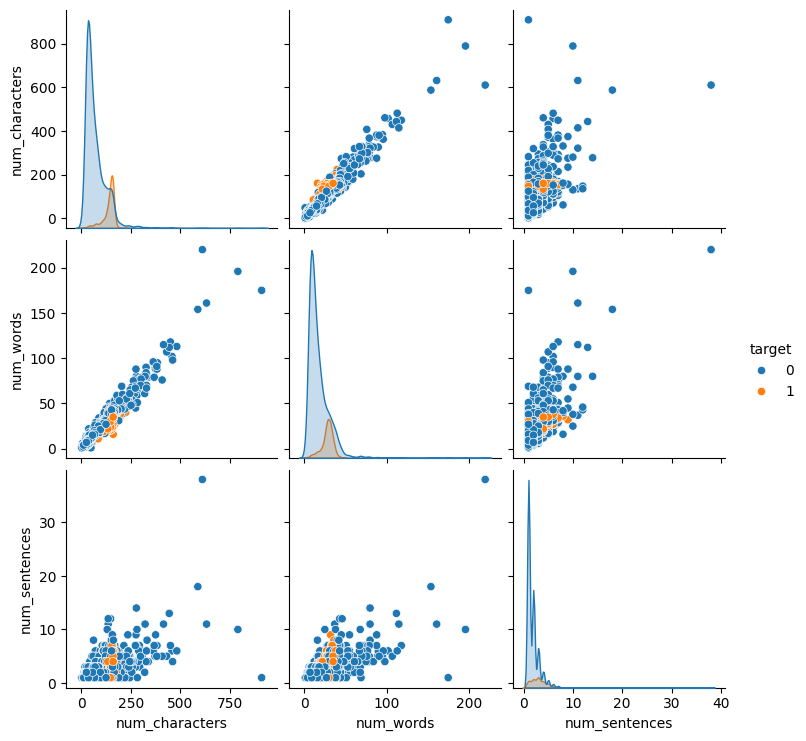

In [72]:
sns.pairplot(df,hue='target')

In [74]:
df[["target","num_characters","num_words","num_sentences"]].corr()

,target,num_characters,num_words,num_sentences
target,1.000000,0.384717,0.262912,0.263939
num_characters,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sentences,0.263939,0.624139,0.679971,1.000000


<Axes: >

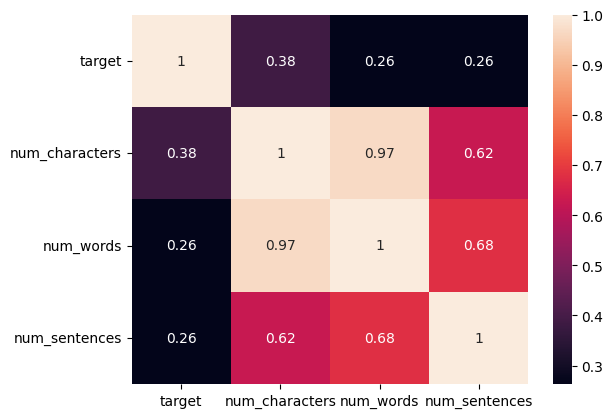

In [76]:
sns.heatmap(df[["target","num_characters","num_words","num_sentences"]].corr(), annot=True)

- From here we can know that num_sentences, num_words, num_chars have a high correlation with each other. When modelling we cant pass all the 3 columns as input due to multi-collinearity so we have to choose 1.
- So what do we choose? The one that has the highest correlation with target! So that is num_characters